# Import the relevant libraries

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
# We can override the default matplotlib styles with those of Seaborn
sns.set()
from sklearn.linear_model import LinearRegression

# Load the data

In [2]:
data = pd.read_csv('real_estate_price_size.csv')
data.head()

,price,size
0,234314.144,643.09
1,228581.528,656.22
2,281626.336,487.29
3,401255.608,1504.75
4,458674.256,1275.46


# Declare the dependent and the independent variables

In [3]:
independent_variables = data['size']
dependent_variable = data['price']

# We need to reshape the independent variable to be a 2D array, as required by scikit-learn

In [5]:
independent_variables_reshaped = independent_variables.values.reshape(-1,1)

# Regression

In [6]:
regression = LinearRegression()
regression.fit(independent_variables_reshaped, dependent_variable)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# R-squared

In [8]:
regression.score(independent_variables_reshaped, dependent_variable)

0.7447391865847587

# The formula for adjusted R² is given by:
# Adjusted R² = 1 - [(1 - R²) * (n - 1) / (n - k - 1)]
# Where:
# R² is the R-squared value,
# n is the number of observations,
# k is the number of predictors in the model.
# This formula adjusts the R-squared value based on the number of predictors, providing a more accurate measure of model fit.

In [21]:
r_squared = regression.score(independent_variables_reshaped, dependent_variable)
print("R-squared:", r_squared)
print("shape of independent variables:", independent_variables_reshaped.shape)
n = independent_variables_reshaped.shape[0] # OR len(independent_variables_reshaped)
print("Number of observations (n):", n)
k = independent_variables_reshaped.shape[1]
print("Number of predictors (k):", k)
adjusted_r_squared = 1 - ((1-r_squared) * (n -1)/(n - k - 1))
print("Adjusted R-squared:", adjusted_r_squared)
def adjusted_r_squared(x, y):
    r_squared_in = regression.score(x, y)
    n_n = x.shape[0]
    k_k = x.shape[1]
    return 1 - ((1-r_squared_in) * (n_n -1)/(n_n - k_k - 1))
adjusted_r_squared_value = adjusted_r_squared(independent_variables_reshaped, dependent_variable)
print("Adjusted R-squared (using function):", adjusted_r_squared_value)

R-squared: 0.7447391865847587
shape of independent variables: (100, 1)
Number of observations (n): 100
Number of predictors (k): 1
Adjusted R-squared: 0.7421344844070521
Adjusted R-squared (using function): 0.7421344844070521


# Coefficients

In [9]:
regression.coef_

array([223.17874259])

# Intercept

In [10]:
regression.intercept_

np.float64(101912.60180122912)

# Predicting values

In [11]:
regression.predict([[570.89]])

array([229323.11416106])

In [12]:
new_data = pd.DataFrame(data=[570.89, 600], columns=['size'])
new_data

,size
0,570.89
1,600.00


In [13]:
regression.predict(new_data)

C:\shiva\coding\python_projects\dear_comrade_data_science_zero_to_hero\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


array([229323.11416106, 235819.84735799])

# Plotting the regression line

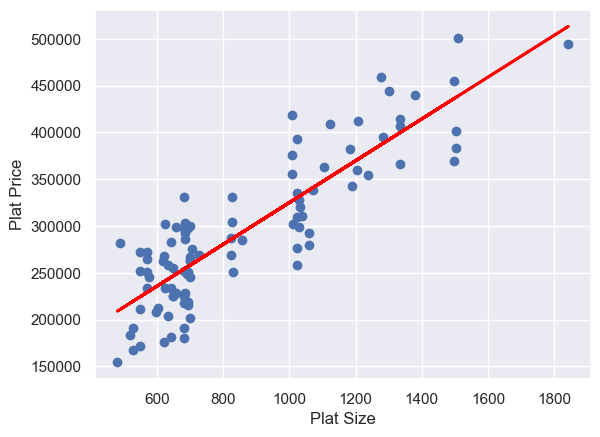

In [15]:
plt.scatter(independent_variables_reshaped, dependent_variable)
dependent_hat = regression.coef_ * independent_variables_reshaped + regression.intercept_
plt.plot(independent_variables, dependent_hat, color='red', lw=2)
plt.xlabel('Plat Size')
plt.ylabel('Plat Price')
plt.show()